<a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/sesiones_practicas/sp_3_Juan_Manuel_Vera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Juan Manuel Vera Osorio
juan.verao@udea.edu.co
1000416823

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [28]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = load_wine()
df = pd.DataFrame(df.data, columns=df.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [29]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [30]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np

# Variable base
datos = df['color_intensity'].values.reshape(-1, 1)

# Índices
indices = np.arange(1, len(datos) + 1)

# Escaladores
standard = StandardScaler().fit_transform(datos).flatten()
minmax = MinMaxScaler().fit_transform(datos).flatten()
robust = RobustScaler().fit_transform(datos).flatten()
zscore = ((datos - datos.mean()) / datos.std()).flatten()

original = datos.flatten()

In [31]:
def calcular_outliers(valores):
    q1 = np.percentile(valores, 25)
    q3 = np.percentile(valores, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

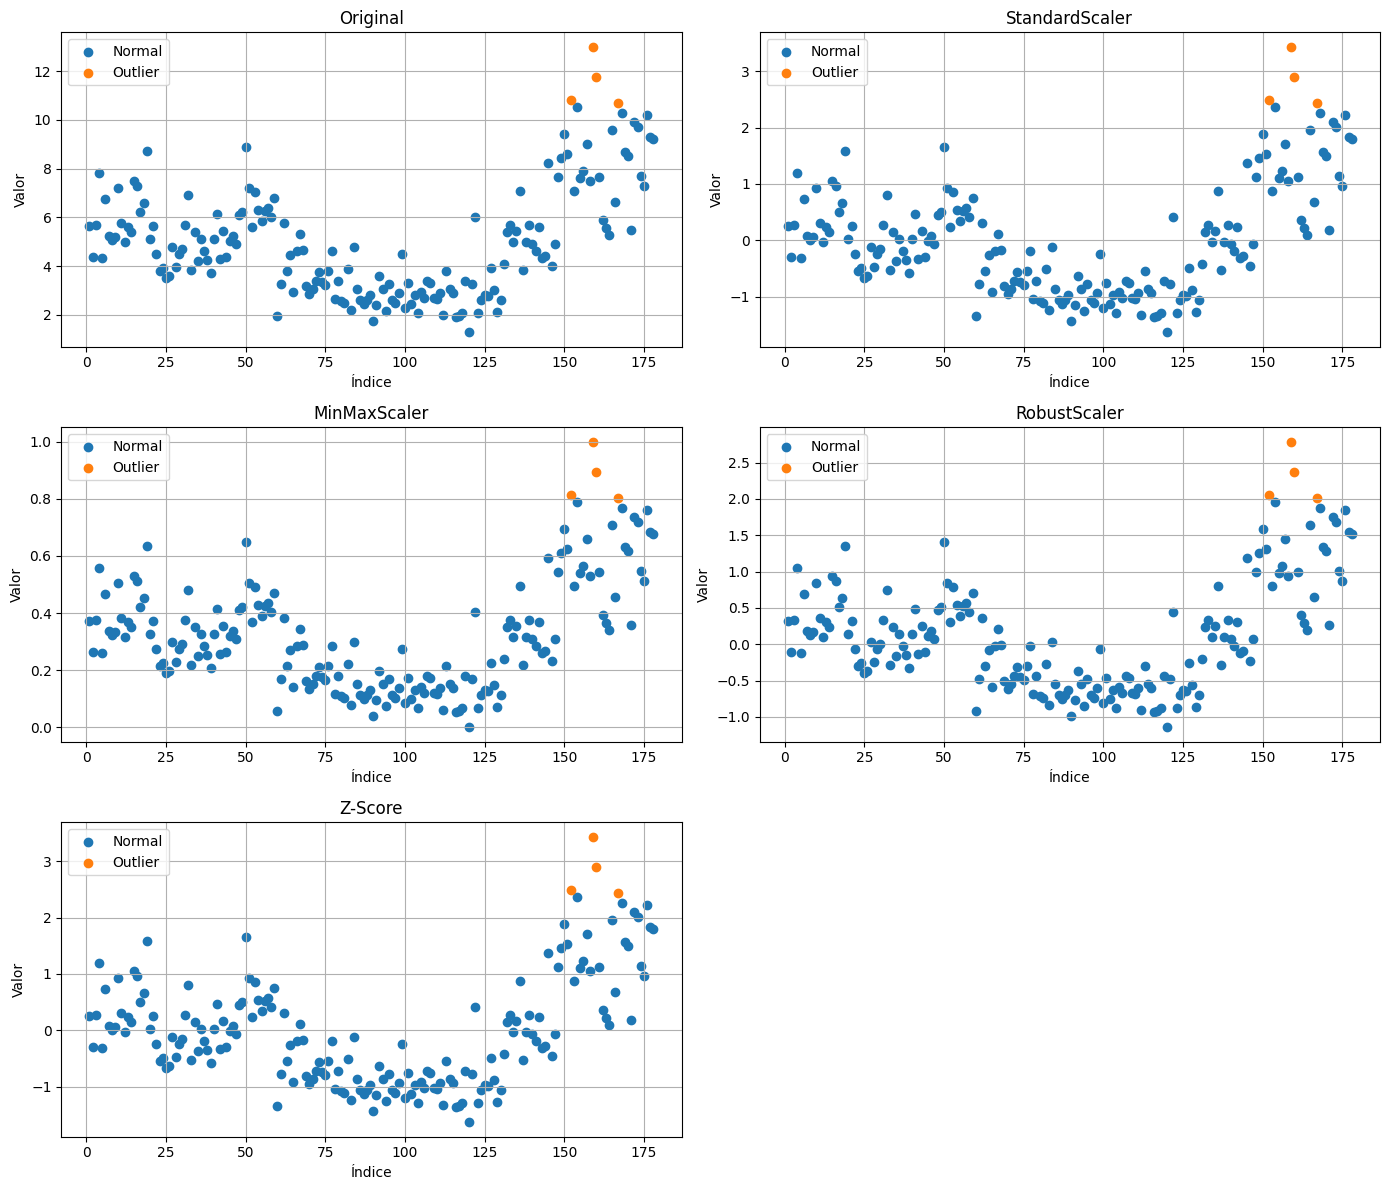

In [32]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Lista de datasets
titulos = [
    "Original",
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler",
    "Z-Score"
]

valores_lista = [
    original,
    standard,
    minmax,
    robust,
    zscore
]

# Graficar
for i, ax in enumerate(axs.flat[:5]):
    valores = valores_lista[i]
    lower, upper = calcular_outliers(valores)

    # Clasificar outliers
    normales = (valores >= lower) & (valores <= upper)
    outliers = ~normales

    # Plot
    ax.scatter(indices[normales], valores[normales], label="Normal")
    ax.scatter(indices[outliers], valores[outliers], label="Outlier")

    ax.set_title(titulos[i])
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")
    ax.grid(True)
    ax.legend()

# Espacio vacío
axs[2,1].axis('off')

plt.tight_layout()
plt.show()

Los resultados muestran que los métodos de escalamiento no alteran el comportamiento ni la tendencia de los datos, sino únicamente su escala. En todos los gráficos se conserva la misma forma y patrón de distribución. Las diferencias observadas corresponden solo a cambios en el rango o en la centralización de los valores.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [33]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
data = load_diabetes()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Ver primeras filas
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [34]:
# Variables a usar
variables = ['bmi', 'bp', 's5']

df = df[variables].copy()

In [35]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Seleccionar UNA variable para visualizar
variable = 'bmi'

# Convertir a formato columna
datos = df[variable].values.reshape(-1, 1)

# Escaladores
scaler_zscore = StandardScaler()
scaler_robust = RobustScaler()

# Transformaciones
datos_zscore = scaler_zscore.fit_transform(datos).flatten()
datos_robust = scaler_robust.fit_transform(datos).flatten()

# Datos originales
datos_originales = datos.flatten()

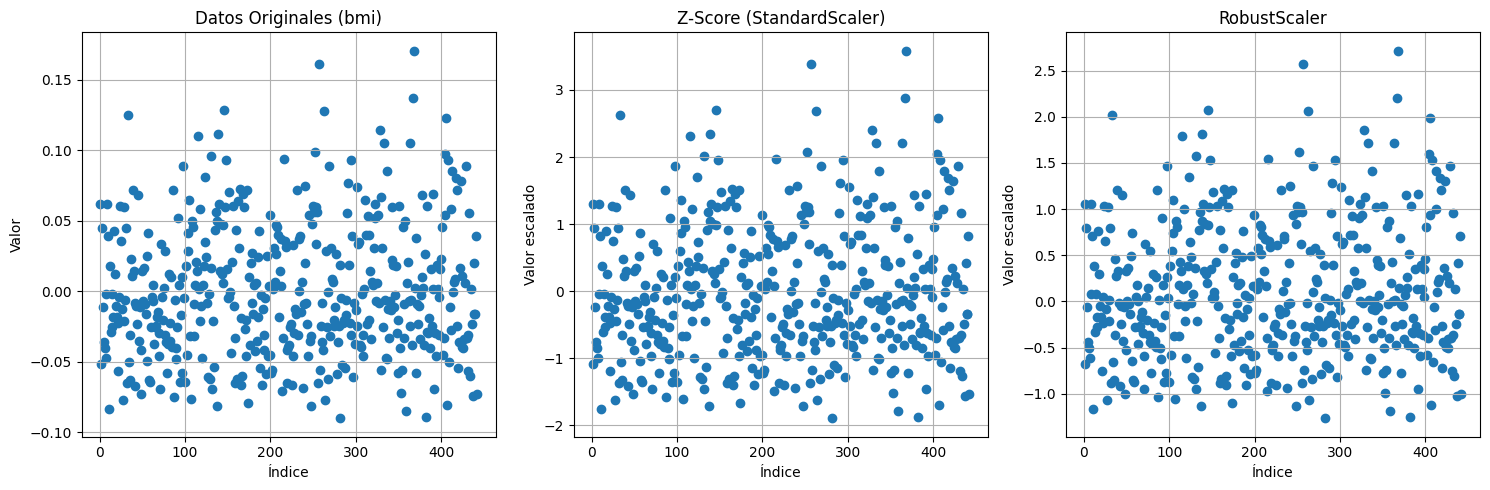

In [36]:
# Índices
indices = np.arange(1, len(datos_originales) + 1)

# Crear figura
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: Original
axs[0].scatter(indices, datos_originales)
axs[0].set_title('Datos Originales (bmi)')
axs[0].set_xlabel('Índice')
axs[0].set_ylabel('Valor')
axs[0].grid(True)

# Gráfico 2: Z-Score
axs[1].scatter(indices, datos_zscore)
axs[1].set_title('Z-Score (StandardScaler)')
axs[1].set_xlabel('Índice')
axs[1].set_ylabel('Valor escalado')
axs[1].grid(True)

# Gráfico 3: RobustScaler
axs[2].scatter(indices, datos_robust)
axs[2].set_title('RobustScaler')
axs[2].set_xlabel('Índice')
axs[2].set_ylabel('Valor escalado')
axs[2].grid(True)

plt.tight_layout()
plt.show()

En las gráficas se observa que la forma de los datos se mantiene constante antes y después del escalamiento, conservando la misma tendencia en la variable bmi. Las diferencias radican únicamente en la escala de los valores: el Z-Score centra los datos en cero, mientras que el RobustScaler reduce la dispersión relativa de valores extremos. A pesar de esto, los puntos más alejados siguen siendo identificables en ambas transformaciones. Esto confirma que el escalamiento no altera la estructura de los datos, solo su escala.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [37]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
data = fetch_california_housing()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Ver datos
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [38]:
variables = ['MedInc', 'AveRooms', 'HouseAge']

df = df[variables].copy()

In [39]:
from sklearn.preprocessing import Normalizer

# Convertir a matriz
datos = df.values

# Inicializar normalizadores
normalizador_l1 = Normalizer(norm='l1')
normalizador_l2 = Normalizer(norm='l2')

# Aplicar normalización
datos_l1 = normalizador_l1.fit_transform(datos)
datos_l2 = normalizador_l2.fit_transform(datos)

# Convertir a DataFrame para facilitar manejo
df_l1 = pd.DataFrame(datos_l1, columns=variables)
df_l2 = pd.DataFrame(datos_l2, columns=variables)

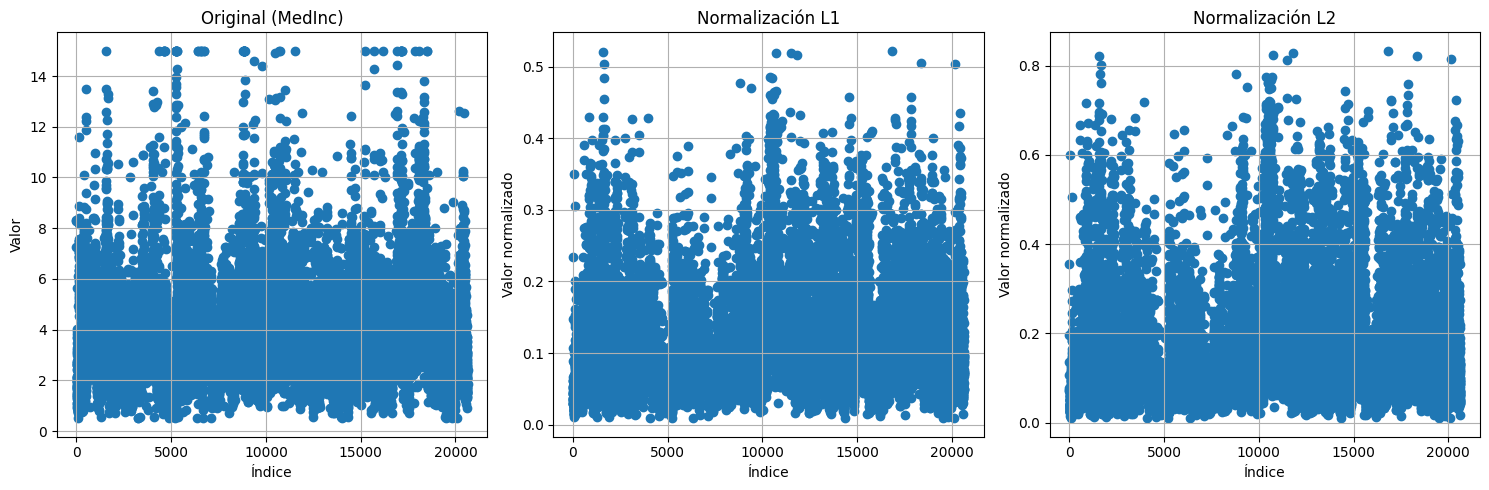

In [40]:
# Seleccionar variable
variable = 'MedInc'

original = df[variable].values
l1 = df_l1[variable].values
l2 = df_l2[variable].values

# Índices
indices = np.arange(1, len(original) + 1)

# Crear figura
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original
axs[0].scatter(indices, original)
axs[0].set_title('Original (MedInc)')
axs[0].set_xlabel('Índice')
axs[0].set_ylabel('Valor')
axs[0].grid(True)

# L1
axs[1].scatter(indices, l1)
axs[1].set_title('Normalización L1')
axs[1].set_xlabel('Índice')
axs[1].set_ylabel('Valor normalizado')
axs[1].grid(True)

# L2
axs[2].scatter(indices, l2)
axs[2].set_title('Normalización L2')
axs[2].set_xlabel('Índice')
axs[2].set_ylabel('Valor normalizado')
axs[2].grid(True)

plt.tight_layout()
plt.show()

En las gráficas se observa que la distribución original de MedInc presenta una amplia dispersión, mientras que tras aplicar L1 y L2 los valores se comprimen en rangos más pequeños. A diferencia del escalamiento, la forma de los datos cambia porque la normalización depende de todas las variables de cada observación. Esto provoca que los valores ya no representen únicamente la variable original, sino su proporción respecto al conjunto. La normalización L2 mantiene una dispersión ligeramente mayor que L1. Esto evidencia que ambas técnicas transforman la escala y modifican algunos valores atipicos.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [41]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
data = load_diabetes()

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [42]:
variables = ['bmi', 'bp', 's5']

df = df[variables].copy()

In [43]:
variable = 'bmi'

# Convertir a array
x = df[variable].values

In [44]:
from scipy.stats import boxcox

# Asegurar valores positivos (necesario para log y Box-Cox)
x_shifted = x - np.min(x) + 1

# 1. Log
log_transform = np.log1p(x_shifted)

# 2. Log reflejado (para asimetría negativa)
x_reflect = np.max(x) - x + 1
log_reflect = np.log1p(x_reflect)

# 3. Cuadrática
cuadratica = x ** 2

# 4. Box-Cox
boxcox_transform, _ = boxcox(x_shifted)

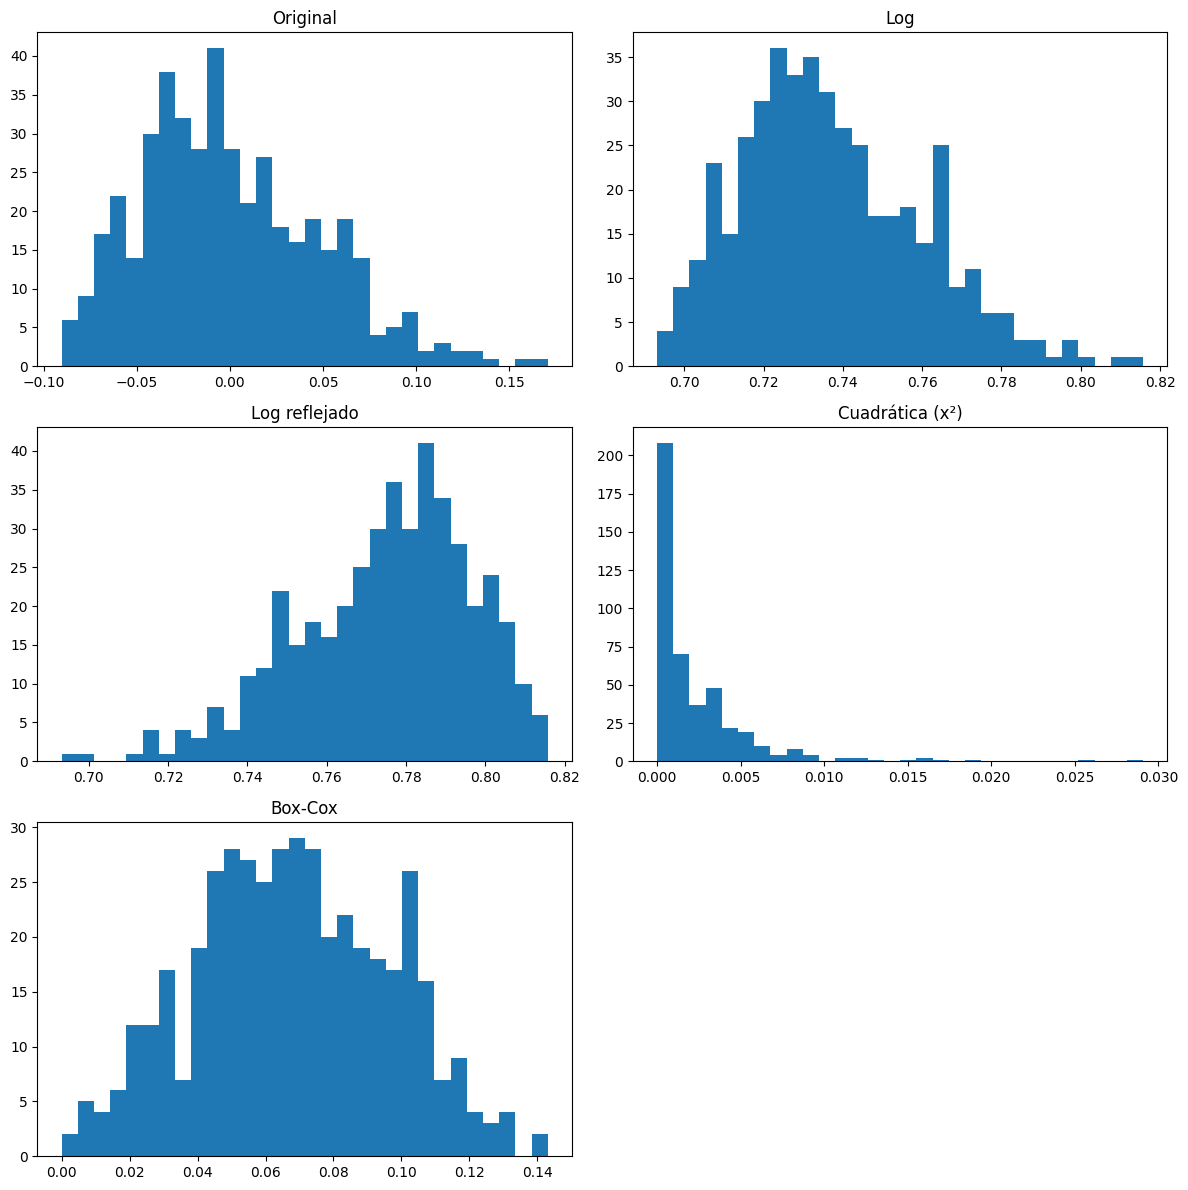

In [45]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# Original
axs[0,0].hist(x, bins=30)
axs[0,0].set_title('Original')

# Log
axs[0,1].hist(log_transform, bins=30)
axs[0,1].set_title('Log')

# Log reflejado
axs[1,0].hist(log_reflect, bins=30)
axs[1,0].set_title('Log reflejado')

# Cuadrática
axs[1,1].hist(cuadratica, bins=30)
axs[1,1].set_title('Cuadrática (x²)')

# Box-Cox
axs[2,0].hist(boxcox_transform, bins=30)
axs[2,0].set_title('Box-Cox')

# Espacio vacío
axs[2,1].axis('off')

plt.tight_layout()
plt.show()

Las transformaciones logarítmicas reducen la asimetría positiva al comprimir valores altos, logrando distribuciones más equilibradas. El log reflejado es útil cuando la asimetría es negativa, invirtiendo la distribución antes de aplicar el log, pero en este ejercicio solo invierte la dirección del sesgo. La transformación cuadrática, en este caso, empeora la asimetría al concentrar valores cercanos a cero. Por otro lado, Box-Cox ajusta automáticamente la transformación óptima, logrando una distribución más cercana a la normal y siendo la transformación con la que estaríamos obteniendo un mejor resultado en los datos.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [46]:
!pip install ucimlrepo

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import PowerTransformer

# Cargar dataset
heart_disease = fetch_ucirepo(id=45)

# Convertir a DataFrame
df = pd.DataFrame(heart_disease.data.features)

# Ver columnas disponibles
print(df.columns)
df.head()

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [48]:
# Seleccionamos variables numéricas
variables = ['chol', 'trestbps', 'thalach']

df[variables].describe()

,chol,trestbps,thalach
count,303.000000,303.000000,303.000000
mean,246.693069,131.689769,149.607261
std,51.776918,17.599748,22.875003
min,126.000000,94.000000,71.000000
25%,211.000000,120.000000,133.500000
50%,241.000000,130.000000,153.000000
75%,275.000000,140.000000,166.000000
max,564.000000,200.000000,202.000000


In [49]:
# Variable original
x = df['chol']

# 1. Raíz cuadrada
sqrt_x = np.sqrt(x)

# 2. Recíproca (evitar división por cero)
reciprocal_x = 1 / (x + 1e-6)

# 3. Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
yeojohnson_x = pt.fit_transform(x.values.reshape(-1, 1)).flatten()

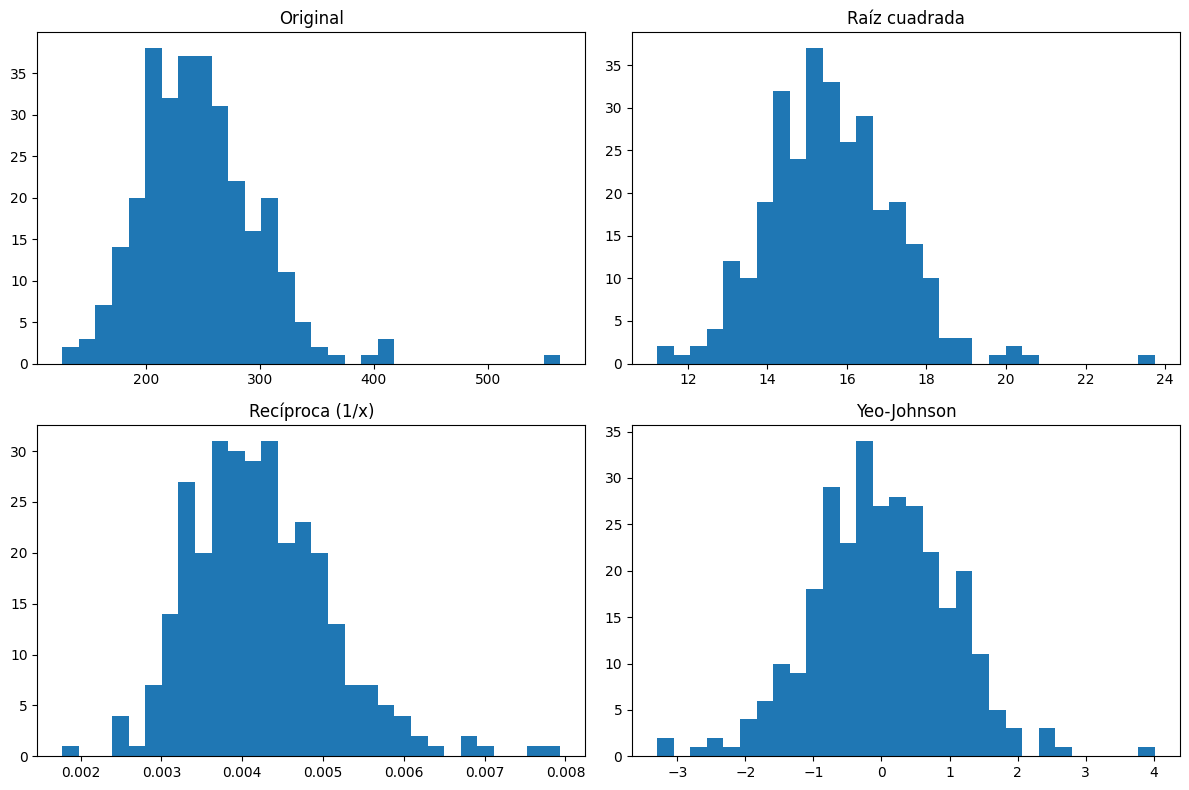

In [50]:
plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 2, 1)
plt.hist(x, bins=30)
plt.title("Original")

# Raíz cuadrada
plt.subplot(2, 2, 2)
plt.hist(sqrt_x, bins=30)
plt.title("Raíz cuadrada")

# Recíproca
plt.subplot(2, 2, 3)
plt.hist(reciprocal_x, bins=30)
plt.title("Recíproca (1/x)")

# Yeo-Johnson
plt.subplot(2, 2, 4)
plt.hist(yeojohnson_x, bins=30)
plt.title("Yeo-Johnson")

plt.tight_layout()
plt.show()

La transformación de raíz cuadrada reduce ligeramente la asimetría, suavizando valores altos sin alterar demasiado la forma original. La transformación recíproca invierte la distribución y puede distorsionar la interpretación de los datos, y su impacto en el comportamiento de los mismos no es tan significativo. Por otro lado, Yeo-Johnson ajusta  la transformación más adecuada, logrando una distribución más simétrica y cercana a la normal, logrando un resultado mejor en terminos generales, esto puede deberse a su flexibilidad y capacidad de manejar valores cero o negativos.